# Ordinal Logistic Regression in R

## Overview

Ordinal logistic regression models outcomes with **three or more ordered categories** — where the categories have a meaningful ranking but the distances between them are not assumed to be equal. It is more parsimonious than multinomial regression for ordered outcomes and respects the ordinal structure of the data.

The most common form is the **proportional odds model**, which assumes that the effect of each predictor is the same across all category thresholds (the proportional odds assumption).

| Model | Use Case |
|---|---|
| Proportional odds model | Ordered outcome, effect of predictors constant across thresholds |
| Partial proportional odds | Some predictors violate proportional odds — relax assumption selectively |
| Multinomial logistic | Unordered categories (see `multinomial_regression.ipynb`) |

> **Key output: odds ratios**  
> Each OR represents the change in odds of being in a *higher* category (vs. all lower categories combined) for a one-unit increase in the predictor.

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | What predicts invertebrate abundance class (absent/rare/common/abundant)? What factors predict habitat quality rating (poor/fair/good/excellent)? |
| **Healthcare** | What predicts pain severity (none/mild/moderate/severe)? What factors predict patient-reported outcome score categories? What predicts cancer stage? |
| **Finance** | What predicts credit rating tier (BBB/A/AA/AAA)? What factors predict customer satisfaction rating (1-5 stars)? |
| **Insurance** | What predicts claim severity category (minor/moderate/major/catastrophic)? What factors predict policy tier chosen? |

---

## Assumptions Checklist

- [ ] **Ordered outcome:** Categories have a meaningful, consistent rank order
- [ ] **Independence of observations:** No repeated measures or clustering
- [ ] **Proportional odds (parallel lines):** The effect of each predictor is consistent across all category thresholds — this is the key assumption to test
- [ ] **Linearity of log-odds:** Continuous predictors have a linear relationship with the log-odds of being in a higher category
- [ ] **No perfect separation:** No predictor perfectly predicts category membership
- [ ] **Adequate cell counts:** At least 5-10 observations per outcome category
- [ ] **No severe multicollinearity:** Check VIF

> **The proportional odds assumption is the most critical** — if violated for a predictor, the single OR across all thresholds is misleading. Test with the Brant test and score test.

---

## Setup

In [1]:
# ── Libraries ────────────────────────────────────────────────────────────────
library(tidyverse)
library(ggplot2)
library(MASS)         # polr() for proportional odds model
library(brant)        # Brant test for proportional odds assumption
library(broom)        # tidy model output
library(effects)      # marginal effects
library(ggeffects)    # ggplot2 marginal effects plots
library(performance)  # model performance metrics

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'MASS' was built under R version 4.4.3"

Attaching package: 'MASS'


The following object is masked from 'p

## Data

We simulate an ordered dataset representing **habitat quality ratings** (Poor / Fair / Good / Excellent) as a function of two continuous environmental predictors. This mirrors real ecological and industry use cases where the response is an expert rating or severity category.


     Poor      Fair      Good Excellent 
       50        50        50        50 

 vegetation_cover  disturbance_index
 Min.   : -9.862   Min.   :-0.3999  
 1st Qu.: 37.798   1st Qu.: 3.6684  
 Median : 49.671   Median : 4.9398  
 Mean   : 49.450   Mean   : 5.0226  
 3rd Qu.: 62.673   3rd Qu.: 6.3496  
 Max.   :104.038   Max.   : 9.9192  

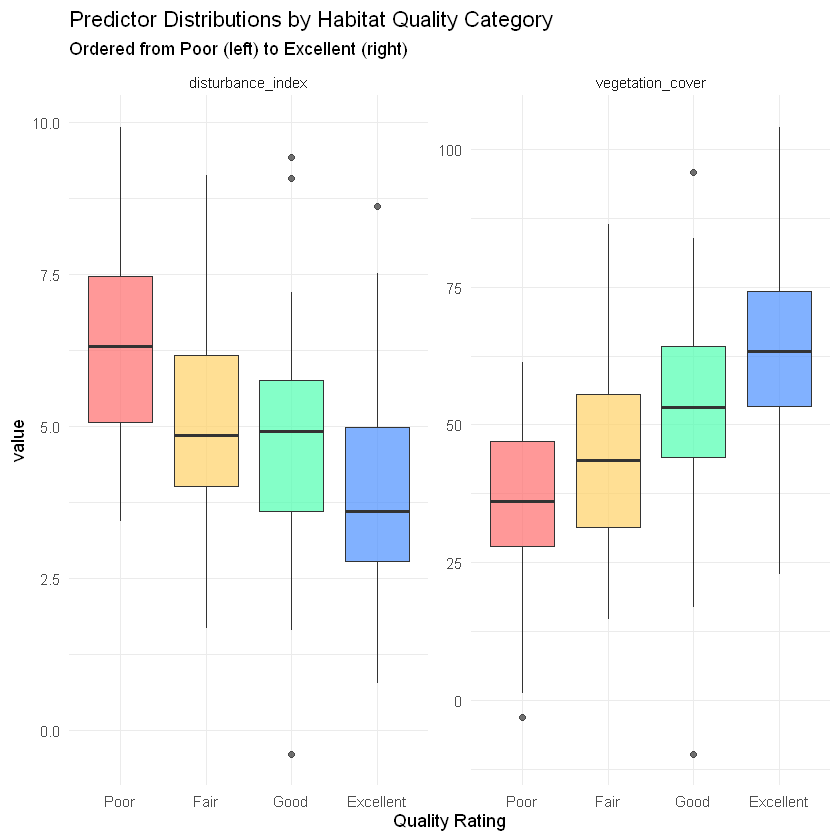

In [2]:
# ── Simulate ordered habitat quality data ─────────────────────────────────────
n <- 200
habitat_data <- tibble(
  vegetation_cover = rnorm(n, mean = 50, sd = 20),   # % vegetation cover
  disturbance_index = rnorm(n, mean = 5, sd = 2),    # disturbance score (higher = worse)
  # Generate latent quality score
  latent_quality = 0.05 * vegetation_cover -
                   0.4  * disturbance_index +
                   rnorm(n, 0, 1)
) %>%
  mutate(
    # Cut latent score into ordered categories
    quality = cut(
      latent_quality,
      breaks = quantile(latent_quality, probs = c(0, 0.25, 0.5, 0.75, 1)),
      labels = c("Poor", "Fair", "Good", "Excellent"),
      include.lowest = TRUE
    ),
    # Ensure ordered factor
    quality = factor(quality,
                     levels = c("Poor", "Fair", "Good", "Excellent"),
                     ordered = TRUE)
  )

# ── Inspect ───────────────────────────────────────────────────────────────────
table(habitat_data$quality)
summary(habitat_data[, c("vegetation_cover", "disturbance_index")])

# ── Exploratory plots ─────────────────────────────────────────────────────────
habitat_data %>%
  pivot_longer(cols = c(vegetation_cover, disturbance_index),
               names_to = "predictor", values_to = "value") %>%
  ggplot(aes(x = quality, y = value, fill = quality)) +
  geom_boxplot(alpha = 0.7) +
  facet_wrap(~predictor, scales = "free_y") +
  scale_fill_manual(values = c("#ff6b6b", "#ffd166", "#4fffb0", "#4a8fff")) +
  labs(title = "Predictor Distributions by Habitat Quality Category",
       subtitle = "Ordered from Poor (left) to Excellent (right)",
       x = "Quality Rating") +
  theme_minimal() +
  theme(legend.position = "none")

---

## Assumptions Testing

### Proportional Odds Assumption

The proportional odds assumption states that the OR for each predictor is constant across all category thresholds. Visually, this means the regression lines for each binary split of the outcome should be parallel.

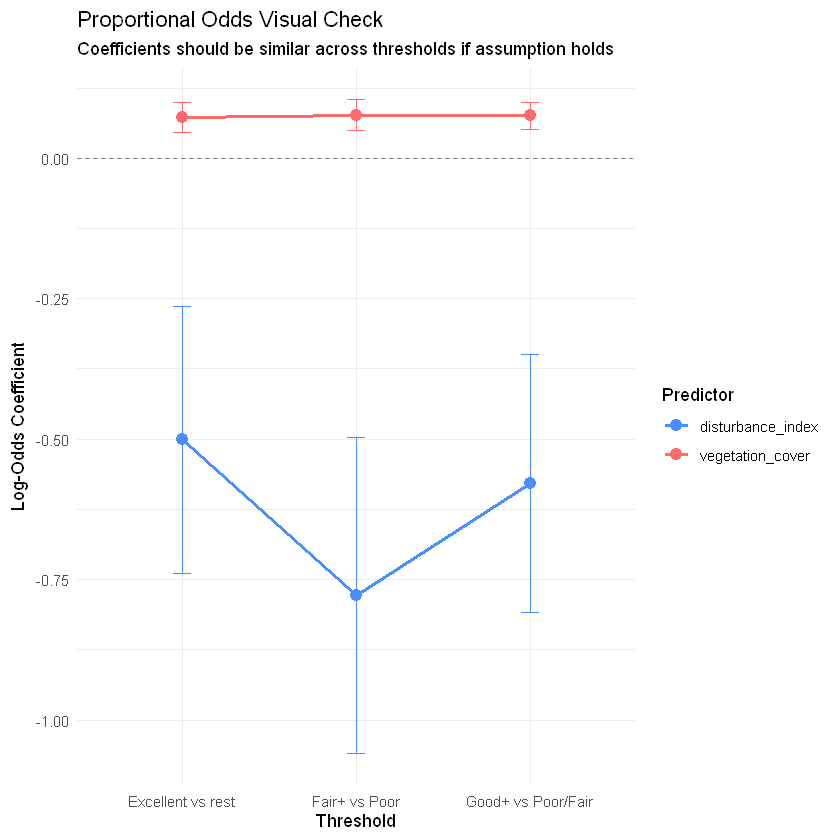

In [3]:
# ── Visual check: fit separate binary logistic models at each threshold ────────
# If proportional odds holds, slopes should be approximately equal
thresholds <- list(
  "Fair+ vs Poor"      = as.integer(habitat_data$quality >= "Fair"),
  "Good+ vs Poor/Fair" = as.integer(habitat_data$quality >= "Good"),
  "Excellent vs rest"  = as.integer(habitat_data$quality == "Excellent")
)

threshold_coefs <- map_dfr(names(thresholds), function(thresh_name) {
  y <- thresholds[[thresh_name]]
  m <- glm(y ~ vegetation_cover + disturbance_index,
            data = habitat_data, family = binomial)
  tidy(m) %>%
    filter(term != "(Intercept)") %>%
    mutate(threshold = thresh_name)
})

# If proportional odds holds, estimates should be similar across thresholds
ggplot(threshold_coefs, aes(x = threshold, y = estimate,
                             color = term, group = term)) +
  geom_line(linewidth = 1) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = estimate - 1.96*std.error,
                    ymax = estimate + 1.96*std.error),
                width = 0.1) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b")) +
  labs(title = "Proportional Odds Visual Check",
       subtitle = "Coefficients should be similar across thresholds if assumption holds",
       x = "Threshold", y = "Log-Odds Coefficient", color = "Predictor") +
  theme_minimal()

In [4]:
# ── Brant test (formal test of proportional odds assumption) ──────────────────
# Fit the model first, then test
model_ord <- MASS::polr(
  quality ~ vegetation_cover + disturbance_index,
  data   = habitat_data,
  Hess   = TRUE   # required for standard errors and Brant test
)

brant::brant(model_ord)
# Output: omnibus test + per-predictor tests
# H0: proportional odds assumption holds
# p > 0.05: assumption not violated
# p < 0.05: assumption violated for that predictor
# — if only one predictor violates: consider partial proportional odds model
# — if omnibus violated: consider multinomial regression instead

---------------------------------------------------- 
Test for		X2	df	probability 
---------------------------------------------------- 
Omnibus			2.87	4	0.58
vegetation_cover	0.07	2	0.97
disturbance_index	2.58	2	0.27
---------------------------------------------------- 

H0: Parallel Regression Assumption holds


---

## Model Fitting

In [5]:
# ── Fit proportional odds model ───────────────────────────────────────────────
model_ord <- MASS::polr(
  quality ~ vegetation_cover + disturbance_index,
  data   = habitat_data,
  Hess   = TRUE,
  method = "logistic"  # logistic link = proportional odds
                       # alternatives: "probit", "cloglog", "cauchit"
)
summary(model_ord)
# Output sections:
# Coefficients: predictor effects (log-odds scale)
# Intercepts: threshold parameters (cutpoints between ordered categories)

# ── P-values (not printed by default) ────────────────────────────────────────
coef_table <- coef(summary(model_ord))
p_values   <- pnorm(abs(coef_table[, "t value"]), lower.tail = FALSE) * 2
cbind(coef_table, p_value = round(p_values, 4))

# ── Odds ratios with 95% CIs ──────────────────────────────────────────────────
# Exponentiate to convert from log-odds to odds ratio scale
or_table <- exp(cbind(
  OR      = coef(model_ord),
  CI_low  = confint(model_ord)[, 1],
  CI_high = confint(model_ord)[, 2]
))
print(round(or_table, 3))
# OR > 1: predictor increases odds of being in a higher quality category
# OR < 1: predictor decreases odds of being in a higher quality category

Call:
MASS::polr(formula = quality ~ vegetation_cover + disturbance_index, 
    data = habitat_data, Hess = TRUE, method = "logistic")

Coefficients:
                     Value Std. Error t value
vegetation_cover   0.07406   0.009201   8.049
disturbance_index -0.60234   0.087206  -6.907

Intercepts:
               Value   Std. Error t value
Poor|Fair      -1.1114  0.5608    -1.9820
Fair|Good       0.6293  0.5579     1.1280
Good|Excellent  2.3495  0.5848     4.0179

Residual Deviance: 425.7837 
AIC: 435.7837 

,Value,Std. Error,t value,p_value
vegetation_cover,0.07406031,0.009201381,8.048826,0.0000
disturbance_index,-0.60233988,0.087206159,-6.907080,0.0000
Poor|Fair,-1.11141028,0.560754281,-1.981992,0.0475
Fair|Good,0.62929268,0.557868382,1.128031,0.2593
Good|Excellent,2.34950443,0.584752344,4.017948,0.0001


Waiting for profiling to be done...

Waiting for profiling to be done...



                     OR CI_low CI_high
vegetation_cover  1.077  1.058   1.097
disturbance_index 0.548  0.459   0.646


---

## Model Evaluation

In [6]:
# ── Predicted categories ──────────────────────────────────────────────────────
pred_class <- predict(model_ord)
pred_probs <- predict(model_ord, type = "probs")

# ── Confusion matrix ──────────────────────────────────────────────────────────
conf_mat <- table(Predicted = pred_class, Actual = habitat_data$quality)
print(conf_mat)
cat(sprintf("\nOverall accuracy: %.1f%%\n",
            sum(diag(conf_mat)) / sum(conf_mat) * 100))

# ── Pseudo R² ────────────────────────────────────────────────────────────────
model_null <- MASS::polr(quality ~ 1, data = habitat_data, Hess = TRUE)
mcfadden   <- 1 - (logLik(model_ord) / logLik(model_null))
cat(sprintf("McFadden R²: %.3f\n", as.numeric(mcfadden)))

# ── AIC ───────────────────────────────────────────────────────────────────────
AIC(model_null, model_ord)

           Actual
Predicted   Poor Fair Good Excellent
  Poor        32   14    4         1
  Fair        13   19   14         4
  Good         5   12   23        15
  Excellent    0    5    9        30

Overall accuracy: 52.0%
McFadden R²: 0.232


,df,AIC
,<dbl>,<dbl>
model_null,3,560.5177
model_ord,5,435.7837


---

## Visualizing Predicted Probabilities

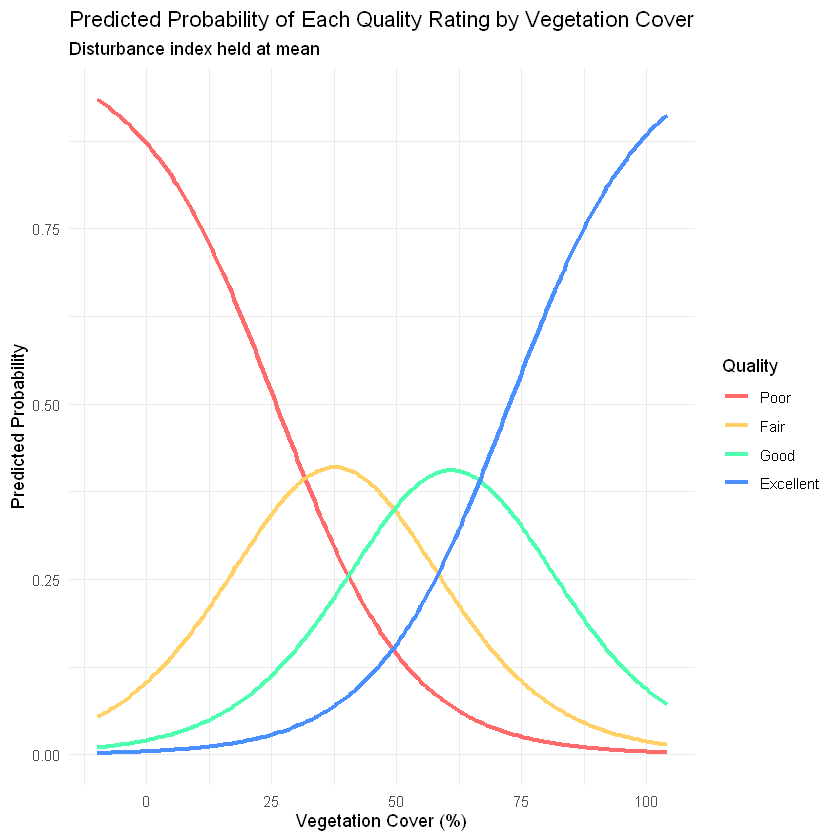

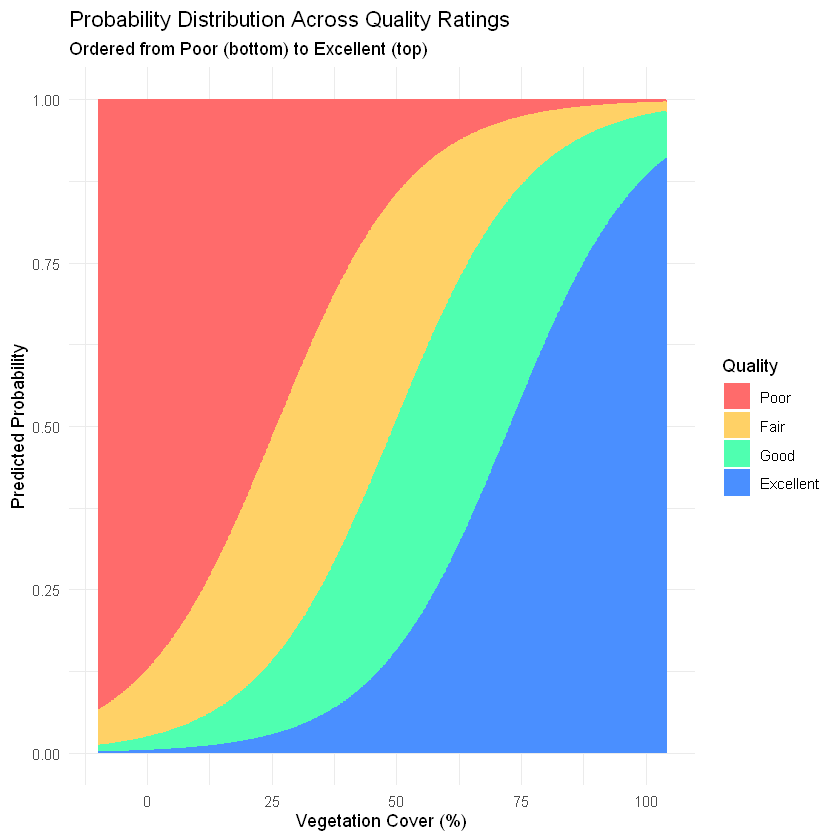

In [7]:
# ── Predicted probability curves over range of vegetation cover ───────────────
pred_grid <- data.frame(
  vegetation_cover  = seq(min(habitat_data$vegetation_cover),
                          max(habitat_data$vegetation_cover),
                          length.out = 200),
  disturbance_index = mean(habitat_data$disturbance_index)
)

pred_grid <- cbind(
  pred_grid,
  predict(model_ord, newdata = pred_grid, type = "probs")
) %>%
  pivot_longer(cols = c(Poor, Fair, Good, Excellent),
               names_to  = "Quality",
               values_to = "Probability") %>%
  mutate(Quality = factor(Quality,
                          levels = c("Poor", "Fair", "Good", "Excellent")))

# Line plot
ggplot(pred_grid,
       aes(x = vegetation_cover, y = Probability, color = Quality)) +
  geom_line(linewidth = 1.2) +
  scale_color_manual(values = c("#ff6b6b", "#ffd166", "#4fffb0", "#4a8fff")) +
  labs(title = "Predicted Probability of Each Quality Rating by Vegetation Cover",
       subtitle = "Disturbance index held at mean",
       x = "Vegetation Cover (%)",
       y = "Predicted Probability") +
  theme_minimal()

# Stacked area plot
ggplot(pred_grid,
       aes(x = vegetation_cover, y = Probability, fill = Quality)) +
  geom_area() +
  scale_fill_manual(values = c("#ff6b6b", "#ffd166", "#4fffb0", "#4a8fff")) +
  labs(title = "Probability Distribution Across Quality Ratings",
       subtitle = "Ordered from Poor (bottom) to Excellent (top)",
       x = "Vegetation Cover (%)", y = "Predicted Probability") +
  theme_minimal()

---

## Reporting Results

In [8]:
# ── Clean OR table ────────────────────────────────────────────────────────────
results_df <- data.frame(
  Predictor = names(coef(model_ord)),
  OR        = round(exp(coef(model_ord)), 3),
  CI_low    = round(exp(confint(model_ord)[,1]), 3),
  CI_high   = round(exp(confint(model_ord)[,2]), 3),
  p_value   = round(p_values[names(coef(model_ord))], 4)
)
print(results_df)

# Standard reporting format:
# "Vegetation cover significantly predicted habitat quality rating
#  (OR = X.XX, 95% CI [X.XX, X.XX], p = .XXX): each percentage point
#  increase in vegetation cover increased the odds of being in a higher
#  quality category by X%. The proportional odds assumption was met
#  (Brant test, p = .XXX). McFadden R² = 0.XX."

Waiting for profiling to be done...

Waiting for profiling to be done...



                          Predictor    OR CI_low CI_high p_value
vegetation_cover   vegetation_cover 1.077  1.058   1.097       0
disturbance_index disturbance_index 0.548  0.459   0.646       0


---

## Common Pitfalls

**1. Not testing the proportional odds assumption**  
This is the defining assumption of the model. Always run the Brant test. If violated for all predictors, multinomial regression is more appropriate. If violated for only one predictor, consider a partial proportional odds model.

**2. Using ordinal regression for unordered categories**  
If categories have no natural order, the proportional odds framework is not meaningful. Use multinomial logistic regression instead.

**3. Forgetting that MASS::polr() uses a different sign convention**  
`polr()` parameterizes the model so that a positive coefficient means the predictor *decreases* the odds of being in a higher category — the opposite of most software. Check the documentation and verify the direction of effects with predicted probabilities.

**4. Not reporting p-values**  
`polr()` does not return p-values by default. Always compute and report them explicitly as shown above.

**5. Treating ordered categories as continuous**  
Assigning numeric codes (1, 2, 3, 4) and running linear regression assumes equal intervals between categories. Ordinal regression makes no such assumption and is more appropriate.

**6. Ignoring sparse categories**  
Very few observations in a category (< 5) makes threshold estimation unreliable. Consider collapsing adjacent categories if conceptually justified.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*